In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Embedding, Dropout, LayerNormalization
from tensorflow.keras.models import Model
import numpy as np

In [2]:
def positional_encoding(position, d_model):
    angle_rads = np.arange(position)[:, np.newaxis] / np.power(10000, (2 * (np.arange(d_model) // 2)) / np.float32(d_model))
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

In [3]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0
        self.depth = d_model // num_heads
        self.wq = Dense(d_model)
        self.wk = Dense(d_model)
        self.wv = Dense(d_model)
        self.dense = Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q, mask):
        batch_size = tf.shape(q)[0]
        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        attention, attention_weights = self.scaled_dot_product_attention(q, k, v, mask)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        attention = tf.reshape(attention, (batch_size, -1, self.d_model))
        output = self.dense(attention)
        return output

    def scaled_dot_product_attention(self, q, k, v, mask):
      matmul_qk = tf.matmul(q, k, transpose_b=True)
      dk = tf.cast(tf.shape(k)[-1], tf.float32)
      scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

      if mask is not None:
          scaled_attention_logits += (mask * -1e9)

      attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
      output = tf.matmul(attention_weights, v)
      return output, attention_weights

In [4]:
class PositionwiseFeedforward(tf.keras.layers.Layer):
    def __init__(self, d_model, dff):
        super(PositionwiseFeedforward, self).__init__()
        self.d_model = d_model
        self.dff = dff
        self.dense1 = Dense(dff, activation='relu')
        self.dense2 = Dense(d_model)

    def call(self, x):
        x = self.dense1(x)
        x = self.dense2(x)
        return x

In [5]:
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedforward(d_model, dff)
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)

    def call(self, x, training, mask):
        attn_output = self.att(x, x, x, mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)
        return out2

In [6]:
class Encoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, maximum_position_encoding, dropout_rate=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model
        self.num_layers = num_layers
        self.embedding = Embedding(input_vocab_size, d_model)
        self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)
        self.dropout = Dropout(dropout_rate)
        self.enc_layers = [TransformerBlock(d_model, num_heads, dff, dropout_rate) for _ in range(num_layers)]

    def call(self, x, training, mask):
        seq_len = tf.shape(x)[1]
        x = self.embedding(x)
        x += self.pos_encoding[:, :seq_len, :]
        x = self.dropout(x, training=training)
        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training=training, mask=mask)
        return x

In [7]:
class Decoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, target_vocab_size, maximum_position_encoding, dropout_rate=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model
        self.num_layers = num_layers
        self.embedding = Embedding(target_vocab_size, d_model)
        self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)
        self.dropout = Dropout(dropout_rate)
        self.dec_layers = [TransformerBlock(d_model, num_heads, dff, dropout_rate) for _ in range(num_layers)]

    def call(self, x, enc_output, training, look_ahead_mask, padding_mask):
        seq_len = tf.shape(x)[1]
        attention_weights = {}
        x = self.embedding(x)
        x += self.pos_encoding[:, :seq_len, :]
        x = self.dropout(x, training=training)
        for i in range(self.num_layers):
            x = self.dec_layers[i](x, training=training, mask=look_ahead_mask)
        return x, attention_weights

In [8]:
class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff,
                 input_vocab_size, target_vocab_size, maximum_position_encoding, dropout_rate=0.1):
        super(Transformer, self).__init__()
        self.encoder = Encoder(num_layers, d_model, num_heads, dff,
                               input_vocab_size, maximum_position_encoding, dropout_rate)
        self.decoder = Decoder(num_layers, d_model, num_heads, dff,
                               target_vocab_size, maximum_position_encoding, dropout_rate)
        self.final_layer = Dense(target_vocab_size)

    def call(self, inputs, training=False, look_ahead_mask=None, padding_mask=None):
        inp, tar = inputs
        enc_output = self.encoder(inp, training=training, mask=padding_mask)
        dec_output, _ = self.decoder(tar, enc_output, training=training,
                                    look_ahead_mask=look_ahead_mask, padding_mask=padding_mask)
        final_output = self.final_layer(dec_output)

        return final_output

In [9]:
num_layers = 4
d_model = 128
num_heads = 8
dff = 512
input_vocab_size = 8500
target_vocab_size = 8000
maximum_position_encoding = 10000
dropout_rate = 0.1

transformer = Transformer(
    num_layers,
    d_model,
    num_heads,
    dff,
    input_vocab_size,
    target_vocab_size,
    maximum_position_encoding,
    dropout_rate
)

inputs = tf.random.uniform((64, 50), dtype=tf.int64, minval=0, maxval=input_vocab_size)
targets = tf.random.uniform((64, 50), dtype=tf.int64, minval=0, maxval=target_vocab_size)

look_ahead_mask = None
padding_mask = None

output = transformer((inputs, targets), training=True, look_ahead_mask=look_ahead_mask, padding_mask=padding_mask)
print(output.shape)


(64, 50, 8000)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Embedding, Dropout, LayerNormalization
from tensorflow.keras.models import Model
import numpy as np

# Positional Encoding function (unchanged)
def positional_encoding(position, d_model):
    angle_rads = np.arange(position)[:, np.newaxis] / np.power(
        10000, (2 * (np.arange(d_model) // 2)) / np.float32(d_model)
    )
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    pos_encoding = angle_rads[np.newaxis, ...]
    return tf.cast(pos_encoding, dtype=tf.float32)

# Fixed MultiHeadAttention with call method
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        self.wq = Dense(d_model)
        self.wk = Dense(d_model)
        self.wv = Dense(d_model)
        self.dense = Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def scaled_dot_product_attention(self, q, k, v, mask):
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_logits = matmul_qk / tf.math.sqrt(dk)
        if mask is not None:
            scaled_logits += (mask * -1e9)
        attention_weights = tf.nn.softmax(scaled_logits, axis=-1)
        output = tf.matmul(attention_weights, v)
        return output, attention_weights

    def call(self, v, k, q, mask=None):
        batch_size = tf.shape(q)[0]

        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)

        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        scaled_attention, attention_weights = self.scaled_dot_product_attention(q, k, v, mask)

        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))

        output = self.dense(concat_attention)

        return output

# Feed Forward Network
class PositionwiseFeedforward(tf.keras.layers.Layer):
    def __init__(self, d_model, dff):
        super().__init__()
        self.dense1 = Dense(dff, activation='relu')
        self.dense2 = Dense(d_model)

    def call(self, x):
        x = self.dense1(x)
        return self.dense2(x)

# Transformer Block
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.att = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedforward(d_model, dff)
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)

    def call(self, x, training=False, mask=None):
        attn_output = self.att(x, x, x, mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)
        return out2

# Encoder
class Encoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size,
                 maximum_position_encoding, dropout_rate=0.1):
        super().__init__()

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = Embedding(input_vocab_size, d_model)
        self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)
        self.dropout = Dropout(dropout_rate)

        self.enc_layers = [TransformerBlock(d_model, num_heads, dff, dropout_rate)
                           for _ in range(num_layers)]

    def call(self, x, training=False, mask=None):
        seq_len = tf.shape(x)[1]

        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))  # Scale embeddings
        x += self.pos_encoding[:, :seq_len, :]

        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training=training, mask=mask)

        return x

# Decoder
class Decoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, target_vocab_size,
                 maximum_position_encoding, dropout_rate=0.1):
        super().__init__()

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = Embedding(target_vocab_size, d_model)
        self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)
        self.dropout = Dropout(dropout_rate)

        self.dec_layers = [TransformerBlock(d_model, num_heads, dff, dropout_rate)
                           for _ in range(num_layers)]

    def call(self, x, enc_output, training=False, look_ahead_mask=None, padding_mask=None):
        seq_len = tf.shape(x)[1]
        attention_weights = {}

        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))  # Scale embeddings
        x += self.pos_encoding[:, :seq_len, :]

        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x = self.dec_layers[i](x, training=training, mask=look_ahead_mask)

        return x, attention_weights

# Transformer model
class Transformer(Model):
    def __init__(self, num_layers, d_model, num_heads, dff,
                 input_vocab_size, target_vocab_size, maximum_position_encoding,
                 dropout_rate=0.1):
        super().__init__()

        self.encoder = Encoder(num_layers, d_model, num_heads, dff,
                               input_vocab_size, maximum_position_encoding, dropout_rate)
        self.decoder = Decoder(num_layers, d_model, num_heads, dff,
                               target_vocab_size, maximum_position_encoding, dropout_rate)
        self.final_layer = Dense(target_vocab_size)

    def call(self, inputs, training=False, look_ahead_mask=None, padding_mask=None):
        inp, tar = inputs

        enc_output = self.encoder(inp, training=training, mask=padding_mask)

        dec_output, _ = self.decoder(tar, enc_output, training=training,
                                    look_ahead_mask=look_ahead_mask, padding_mask=padding_mask)

        final_output = self.final_layer(dec_output)

        return final_output

# Example hyperparameters
num_layers = 2
d_model = 128
num_heads = 8
dff = 512
input_vocab_size = 8500
target_vocab_size = 8000
maximum_position_encoding = 10000
dropout_rate = 0.1

# Instantiate the Transformer
transformer = Transformer(
    num_layers,
    d_model,
    num_heads,
    dff,
    input_vocab_size,
    target_vocab_size,
    maximum_position_encoding,
    dropout_rate
)

# Dummy input data
inputs = tf.random.uniform((64, 50), dtype=tf.int64, minval=0, maxval=input_vocab_size)
targets = tf.random.uniform((64, 50), dtype=tf.int64, minval=0, maxval=target_vocab_size)

look_ahead_mask = None
padding_mask = None

# Forward pass
output = transformer((inputs, targets), training=True,
                     look_ahead_mask=look_ahead_mask, padding_mask=padding_mask)

print(output.shape)  # Expected: (64, 50, 8000)


(64, 50, 8000)


FULL STEP-BY-STEP TRANSFORMER WITH TRAIN + TEST

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.1


STEP 1 — Positional Encoding

In [11]:
def positional_encoding(position, d_model):
    """
    Adds positional information using sinusoidal waves.
    """
    angle_rads = np.arange(position)[:, np.newaxis] / np.power(
        10000,
        (2 * (np.arange(d_model)[np.newaxis, :] // 2)) / np.float32(d_model)
    )

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)


STEP 2 — Scaled Dot-Product Attention
Based on "Attention Is All You Need"

In [12]:
def scaled_dot_product_attention(q, k, v, mask=None):

    matmul_qk = tf.matmul(q, k, transpose_b=True)

    dk = tf.cast(tf.shape(k)[-1], tf.float32)
    scaled_logits = matmul_qk / tf.math.sqrt(dk)

    if mask is not None:
        scaled_logits += (mask * -1e9)

    attention_weights = tf.nn.softmax(scaled_logits, axis=-1)
    output = tf.matmul(attention_weights, v)

    return output, attention_weights


STEP 3 — Multi-Head Attention

In [13]:
class MultiHeadAttention(tf.keras.layers.Layer):

    def __init__(self, d_model, num_heads):
        super().__init__()

        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)

        self.dense = tf.keras.layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, x):

        batch_size = tf.shape(x)[0]

        q = self.wq(x)
        k = self.wk(x)
        v = self.wv(x)

        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        scaled_attention, _ = scaled_dot_product_attention(q, k, v)

        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])

        concat_attention = tf.reshape(
            scaled_attention,
            (batch_size, -1, self.d_model)
        )

        output = self.dense(concat_attention)

        return output


STEP 4 — Feed Forward Network

In [14]:
def feed_forward_network(d_model, dff):
    return tf.keras.Sequential([
        tf.keras.layers.Dense(dff, activation='relu'),
        tf.keras.layers.Dense(d_model)
    ])


STEP 5 — Encoder Layer

In [15]:
class EncoderLayer(tf.keras.layers.Layer):

    def __init__(self, d_model, num_heads, dff):
        super().__init__()

        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = feed_forward_network(d_model, dff)

        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

    def call(self, x):

        attn_output = self.mha(x)
        out1 = self.norm1(x + attn_output)

        ffn_output = self.ffn(out1)
        out2 = self.norm2(out1 + ffn_output)

        return out2


STEP 6 — Full Transformer (Encoder Only for Toy Task)

In [16]:
class SimpleTransformer(tf.keras.Model):

    def __init__(self, num_layers, d_model, num_heads, dff, vocab_size, max_len):
        super().__init__()

        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pos_encoding = positional_encoding(max_len, d_model)

        self.enc_layers = [
            EncoderLayer(d_model, num_heads, dff)
            for _ in range(num_layers)
        ]

        self.final_layer = tf.keras.layers.Dense(vocab_size)

    def call(self, x):

        seq_len = tf.shape(x)[1]

        x = self.embedding(x)
        x += self.pos_encoding[:, :seq_len, :]

        for layer in self.enc_layers:
            x = layer(x)

        return self.final_layer(x)


STEP 7 — Create Toy Dataset (Reverse Sequence)

In [17]:
vocab_size = 50
seq_len = 6
batch_size = 64

def generate_data(num_samples):
    x = np.random.randint(1, vocab_size, size=(num_samples, seq_len))
    y = np.flip(x, axis=1)
    return x, y

X_train, y_train = generate_data(2000)
X_test, y_test = generate_data(400)

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)


STEP 8 — Training

In [18]:
model = SimpleTransformer(
    num_layers=2,
    d_model=64,
    num_heads=4,
    dff=128,
    vocab_size=vocab_size,
    max_len=seq_len
)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam()

EPOCHS = 20

train_losses = []
test_losses = []

for epoch in range(EPOCHS):

    train_loss = 0

    for inp, tar in train_dataset:
        with tf.GradientTape() as tape:
            predictions = model(inp)
            loss = loss_fn(tar, predictions)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        train_loss += loss.numpy()

    train_losses.append(train_loss)

    test_loss = 0
    for inp, tar in test_dataset:
        predictions = model(inp)
        loss = loss_fn(tar, predictions)
        test_loss += loss.numpy()

    test_losses.append(test_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")


Epoch 1, Train Loss: 126.8018, Test Loss: 27.3144
Epoch 2, Train Loss: 124.3334, Test Loss: 27.0945
Epoch 3, Train Loss: 116.6012, Test Loss: 20.5325
Epoch 4, Train Loss: 41.7006, Test Loss: 1.9899
Epoch 5, Train Loss: 4.3368, Test Loss: 0.4803
Epoch 6, Train Loss: 1.5998, Test Loss: 0.2717
Epoch 7, Train Loss: 1.0063, Test Loss: 0.1884
Epoch 8, Train Loss: 0.7260, Test Loss: 0.1416
Epoch 9, Train Loss: 0.5579, Test Loss: 0.1116
Epoch 10, Train Loss: 0.4463, Test Loss: 0.0908
Epoch 11, Train Loss: 0.3674, Test Loss: 0.0757
Epoch 12, Train Loss: 0.3089, Test Loss: 0.0643
Epoch 13, Train Loss: 0.2642, Test Loss: 0.0554
Epoch 14, Train Loss: 0.2291, Test Loss: 0.0484
Epoch 15, Train Loss: 0.2009, Test Loss: 0.0427
Epoch 16, Train Loss: 0.1778, Test Loss: 0.0380
Epoch 17, Train Loss: 0.1587, Test Loss: 0.0340
Epoch 18, Train Loss: 0.1427, Test Loss: 0.0307
Epoch 19, Train Loss: 0.1290, Test Loss: 0.0278
Epoch 20, Train Loss: 0.1173, Test Loss: 0.0254


STEP 9 — Plot Training & Testing Loss

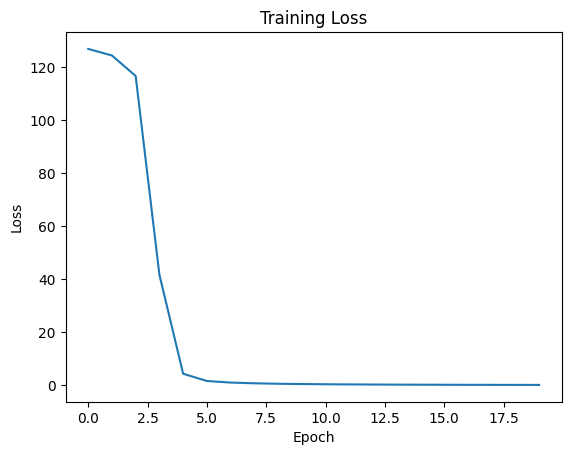

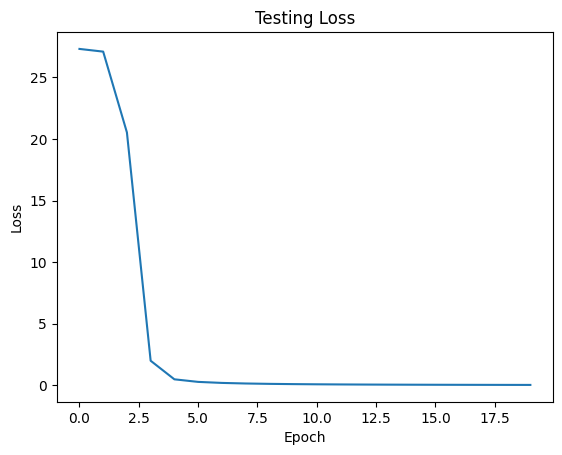

In [19]:
plt.figure()
plt.title("Training Loss")
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.title("Testing Loss")
plt.plot(test_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


STEP 10 — Test Prediction

In [20]:
sample_input = X_test[:1]

prediction = model(sample_input)
predicted_tokens = tf.argmax(prediction, axis=-1)

print("Input Sequence:")
print(sample_input)

print("Expected Reversed:")
print(np.flip(sample_input, axis=1))

print("Model Prediction:")
print(predicted_tokens.numpy())


Input Sequence:
[[24 24 36 43 40 12]]
Expected Reversed:
[[12 40 43 36 24 24]]
Model Prediction:
[[12 40 43 36 24 24]]


STEP 1 — Imports

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Layer, Dense, Embedding, LayerNormalization, Dropout
from tensorflow.keras.models import Model


STEP 2 — Positional Encoding

In [22]:
def positional_encoding(max_len, d_model):
    pos = np.arange(max_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    
    angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    
    # apply sin to even indices
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    # apply cos to odd indices
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    
    return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)


STEP 3 — Multi-Head Attention Layer

In [23]:
class MultiHeadAttention(Layer):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        
        assert d_model % num_heads == 0
        
        self.depth = d_model // num_heads
        
        self.wq = Dense(d_model)
        self.wk = Dense(d_model)
        self.wv = Dense(d_model)
        
        self.dense = Dense(d_model)
        
    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0,2,1,3])
    
    def call(self, q, k, v, mask=None):
        batch_size = tf.shape(q)[0]
        
        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)
        
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)
        
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
        
        if mask is not None:
            scaled_attention_logits += (mask * -1e9)
        
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        
        output = tf.matmul(attention_weights, v)
        
        output = tf.transpose(output, perm=[0,2,1,3])
        concat_attention = tf.reshape(output, (batch_size, -1, self.d_model))
        
        return self.dense(concat_attention), attention_weights


STEP 4 — Encoder Layer

In [24]:
class EncoderLayer(Layer):
    def __init__(self, d_model, num_heads, dff):
        super().__init__()
        
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = tf.keras.Sequential([
            Dense(dff, activation='relu'),
            Dense(d_model)
        ])
        
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        
    def call(self, x):
        attn_output, attn_weights = self.mha(x, x, x)
        out1 = self.layernorm1(x + attn_output)
        
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + ffn_output)
        
        return out2, attn_weights


STEP 5 — Decoder Layer

In [25]:
class DecoderLayer(Layer):
    def __init__(self, d_model, num_heads, dff):
        super().__init__()
        
        self.mha1 = MultiHeadAttention(d_model, num_heads)
        self.mha2 = MultiHeadAttention(d_model, num_heads)
        
        self.ffn = tf.keras.Sequential([
            Dense(dff, activation='relu'),
            Dense(d_model)
        ])
        
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.layernorm3 = LayerNormalization(epsilon=1e-6)
        
    def call(self, x, enc_output):
        attn1, block1 = self.mha1(x, x, x)
        out1 = self.layernorm1(attn1 + x)
        
        attn2, block2 = self.mha2(out1, enc_output, enc_output)
        out2 = self.layernorm2(attn2 + out1)
        
        ffn_output = self.ffn(out2)
        out3 = self.layernorm3(ffn_output + out2)
        
        return out3, block1, block2


STEP 6 — Build Transformer Model

In [26]:
class Transformer(Model):
    def __init__(self, vocab_size, d_model=64, num_heads=4, dff=128):
        super().__init__()
        
        self.embedding = Embedding(vocab_size, d_model)
        self.pos_encoding = positional_encoding(50, d_model)
        
        self.encoder = EncoderLayer(d_model, num_heads, dff)
        self.decoder = DecoderLayer(d_model, num_heads, dff)
        
        self.final_layer = Dense(vocab_size)
        
    def call(self, inp, tar):
        seq_len = tf.shape(inp)[1]
        
        x = self.embedding(inp)
        x += self.pos_encoding[:, :seq_len, :]
        
        enc_output, enc_attn = self.encoder(x)
        
        y = self.embedding(tar)
        y += self.pos_encoding[:, :seq_len, :]
        
        dec_output, _, cross_attn = self.decoder(y, enc_output)
        
        final_output = self.final_layer(dec_output)
        
        return final_output, cross_attn


STEP 7 — Train

In [27]:
vocab_size = 50
model = Transformer(vocab_size)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam()

# Toy data
X = tf.constant([[1,2,3]])
Y = tf.constant([[4,5,6]])

for epoch in range(200):
    with tf.GradientTape() as tape:
        predictions, _ = model(X, Y)
        loss = loss_fn(Y, predictions)
        
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss {loss.numpy()}")


Epoch 0, Loss 3.891578435897827
Epoch 50, Loss 0.019832605496048927
Epoch 100, Loss 0.002584359608590603
Epoch 150, Loss 0.0013310564681887627


PART 2 — GPT (Decoder-Only)

In [28]:
class GPT(Model):
    def __init__(self, vocab_size, d_model=64, num_heads=4, dff=128):
        super().__init__()
        
        self.embedding = Embedding(vocab_size, d_model)
        self.pos_encoding = positional_encoding(50, d_model)
        
        self.decoder = DecoderLayer(d_model, num_heads, dff)
        self.final_layer = Dense(vocab_size)
        
    def call(self, x):
        seq_len = tf.shape(x)[1]
        
        x_embed = self.embedding(x)
        x_embed += self.pos_encoding[:, :seq_len, :]
        
        output, _, _ = self.decoder(x_embed, x_embed)
        
        return self.final_layer(output)


GPT Training (Next Token Prediction)

In [29]:
gpt = GPT(vocab_size)
optimizer = tf.keras.optimizers.Adam()

for epoch in range(200):
    with tf.GradientTape() as tape:
        logits = gpt(X)
        loss = loss_fn(X, logits)
        
    grads = tape.gradient(loss, gpt.trainable_variables)
    optimizer.apply_gradients(zip(grads, gpt.trainable_variables))
    
    if epoch % 50 == 0:
        print("GPT Epoch:", epoch, "Loss:", loss.numpy())


GPT Epoch: 0 Loss: 5.450781
GPT Epoch: 50 Loss: 0.5013262
GPT Epoch: 100 Loss: 0.004653159
GPT Epoch: 150 Loss: 0.0022544686


PART 3 — Attention Heatmap

In [30]:
def plot_attention(attention):
    plt.figure(figsize=(6,5))
    plt.imshow(attention[0][0], cmap='viridis')
    plt.colorbar()
    plt.title("Attention Heatmap")
    plt.xlabel("Key")
    plt.ylabel("Query")
    plt.show()


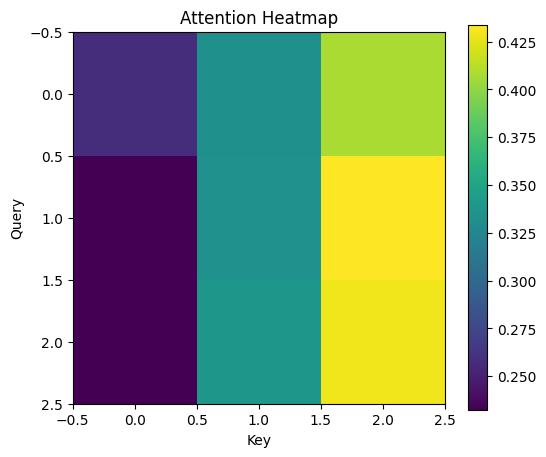

In [31]:
_, attention = model(X, Y)
plot_attention(attention)


In [32]:
def create_causal_mask(size):
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask  # shape (seq_len, seq_len)

In [33]:
def scaled_dot_product_attention(q, k, v, mask):
    matmul_qk = tf.matmul(q, k, transpose_b=True)
    
    dk = tf.cast(tf.shape(k)[-1], tf.float32)
    scaled_logits = matmul_qk / tf.math.sqrt(dk)

    if mask is not None:
        scaled_logits += (mask * -1e9)

    attention_weights = tf.nn.softmax(scaled_logits, axis=-1)
    output = tf.matmul(attention_weights, v)

    return output, attention_weights


In [34]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)
        self.dense = tf.keras.layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0,2,1,3])

    def call(self, x, mask):
        batch_size = tf.shape(x)[0]

        q = self.wq(x)
        k = self.wk(x)
        v = self.wv(x)

        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        attn_output, attn_weights = scaled_dot_product_attention(q, k, v, mask)

        attn_output = tf.transpose(attn_output, perm=[0,2,1,3])
        concat = tf.reshape(attn_output, (batch_size, -1, self.d_model))

        return self.dense(concat), attn_weights


In [35]:
class GPTBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout=0.1):
        super().__init__()

        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model)
        ])

        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = tf.keras.layers.Dropout(dropout)
        self.dropout2 = tf.keras.layers.Dropout(dropout)

    def call(self, x, training, mask):
        attn_output, attn_weights = self.mha(x, mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)

        return out2, attn_weights


In [51]:
class GPTBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout=0.1):
        super().__init__()

        self.mha = MultiHeadAttention(d_model, num_heads)

        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation="relu"),
            tf.keras.layers.Dense(d_model)
        ])

        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = tf.keras.layers.Dropout(dropout)
        self.dropout2 = tf.keras.layers.Dropout(dropout)

    def call(self, inputs, training=None, mask=None):

        attn_output, attn_weights = self.mha(
            inputs,
            mask=mask
        )

        attn_output = self.dropout1(
            attn_output,
            training=training
        )

        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(
            out1,
            training=training
        )

        ffn_output = self.dropout2(
            ffn_output,
            training=training
        )

        out2 = self.layernorm2(out1 + ffn_output)

        return out2, attn_weights


In [52]:
class MiniGPT(tf.keras.Model):
    def __init__(self, vocab_size, max_len,
                 num_layers=2,
                 d_model=128,
                 num_heads=4,
                 dff=512):

        super().__init__()

        self.max_len = max_len
        self.d_model = d_model

        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pos_embedding = tf.keras.layers.Embedding(max_len, d_model)

        self.blocks = [
            GPTBlock(d_model, num_heads, dff)
            for _ in range(num_layers)
        ]

        self.final_layer = tf.keras.layers.Dense(vocab_size)

    def call(self, inputs, training=None):

        # inputs shape: (batch, seq_len)
        batch_size = tf.shape(inputs)[0]
        seq_len = tf.shape(inputs)[1]

        # Word embeddings
        x = self.embedding(inputs)  # (batch, seq_len, d_model)

        # Positional embeddings
        positions = tf.range(0, seq_len)
        positions = self.pos_embedding(positions)  # (seq_len, d_model)

        # Expand to batch dimension
        positions = tf.expand_dims(positions, 0)
        x = x + positions

        # Create causal mask
        mask = tf.linalg.band_part(
            tf.ones((seq_len, seq_len)), -1, 0
        )
        mask = 1 - mask  # invert
        mask = mask[tf.newaxis, tf.newaxis, :, :]
        mask = tf.cast(mask, tf.float32)

        attention_weights = {}

        for i, block in enumerate(self.blocks):
            x, attn = block(
                x,
                training=training,
                mask=mask
            )
            attention_weights[f"block_{i+1}"] = attn

        logits = self.final_layer(x)

        return logits, attention_weights


In [55]:
sentences = [
    "i love deep learning",
    "i love machine learning",
    "transformers are powerful",
    "gpt generates text",
    "attention is all you need"
]


In [56]:
tokenizer = tf.keras.preprocessing.text.Tokenizer(filters='')
tokenizer.fit_on_texts(sentences)

vocab_size = len(tokenizer.word_index) + 1
print("Vocab Size:", vocab_size)

sequences = tokenizer.texts_to_sequences(sentences)

max_len = max(len(seq) for seq in sequences)

X = []
Y = []

for seq in sequences:
    for i in range(1, len(seq)):
        input_seq = seq[:i]
        target_seq = seq[1:i+1]

        input_seq = tf.keras.preprocessing.sequence.pad_sequences(
            [input_seq], maxlen=max_len, padding='pre')[0]

        target_seq = tf.keras.preprocessing.sequence.pad_sequences(
            [target_seq], maxlen=max_len, padding='pre')[0]

        X.append(input_seq)
        Y.append(target_seq)

X = np.array(X)
Y = np.array(Y)

print("X shape:", X.shape)
print("Y shape:", Y.shape)


Vocab Size: 17
X shape: (14, 5)
Y shape: (14, 5)


In [57]:
def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]

    angle_rates = 1 / np.power(10000, (2*(i//2))/np.float32(d_model))
    angle_rads = pos * angle_rates

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.cast(angle_rads, dtype=tf.float32)


In [58]:
def create_causal_mask(size):
    mask = tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask


In [59]:
class GPTBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff):
        super().__init__()

        self.supports_masking = True

        self.ln1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.mha = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads
        )

        self.ln2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model)
        ])

    def call(self, x, training=False):

        seq_len = tf.shape(x)[1]
        causal_mask = create_causal_mask(seq_len)

        # Pre-Norm
        attn_input = self.ln1(x)

        attn_output, attn_weights = self.mha(
            attn_input,
            attn_input,
            attention_mask=causal_mask,
            return_attention_scores=True
        )

        x = x + attn_output

        ffn_input = self.ln2(x)
        ffn_output = self.ffn(ffn_input)

        x = x + ffn_output

        return x, attn_weights


In [60]:
class MiniGPT(tf.keras.Model):
    def __init__(self, vocab_size, max_len, d_model=128, num_heads=4, dff=256, num_layers=2):
        super().__init__()

        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pos_encoding = positional_encoding(max_len, d_model)

        self.blocks = [
            GPTBlock(d_model, num_heads, dff)
            for _ in range(num_layers)
        ]

        self.ln_f = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.final_layer = tf.keras.layers.Dense(vocab_size)

    def call(self, x, training=False):

        seq_len = tf.shape(x)[1]

        x = self.embedding(x)
        x = x + self.pos_encoding[:seq_len, :]

        attention_weights = {}

        for i, block in enumerate(self.blocks):
            x, attn = block(x, training=training)
            attention_weights[f'block_{i+1}'] = attn

        x = self.ln_f(x)

        logits = self.final_layer(x)

        return logits, attention_weights


In [61]:
model = MiniGPT(vocab_size, max_len)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True,
    reduction="none"
)


In [62]:
for epoch in range(200):

    with tf.GradientTape() as tape:

        logits, _ = model(X, training=True)

        loss = loss_fn(Y, logits)

        mask = tf.cast(tf.not_equal(Y, 0), tf.float32)
        loss = loss * mask

        loss = tf.reduce_sum(loss) / tf.reduce_sum(mask)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    if epoch % 20 == 0:
        print(f"Epoch {epoch} Loss {loss.numpy():.4f}")


Epoch 0 Loss 3.4393
Epoch 20 Loss 1.1328
Epoch 40 Loss 0.1207
Epoch 60 Loss 0.1007
Epoch 80 Loss 0.0998
Epoch 100 Loss 0.0996
Epoch 120 Loss 0.0995
Epoch 140 Loss 0.0994
Epoch 160 Loss 0.0993
Epoch 180 Loss 0.0993


In [63]:
def generate_text(model, start_text, max_tokens=10):

    input_seq = tokenizer.texts_to_sequences([start_text])[0]

    for _ in range(max_tokens):

        padded = tf.keras.preprocessing.sequence.pad_sequences(
            [input_seq], maxlen=max_len, padding='pre'
        )

        logits, _ = model(padded, training=False)

        next_token_logits = logits[0, -1, :]
        next_token = tf.argmax(next_token_logits).numpy()

        input_seq.append(next_token)

    return tokenizer.sequences_to_texts([input_seq])[0]


In [64]:
print(generate_text(model, "i love"))
print(generate_text(model, "transformers"))


i love machine learning learning need need need need need need need
transformers are powerful need need need need need need need need


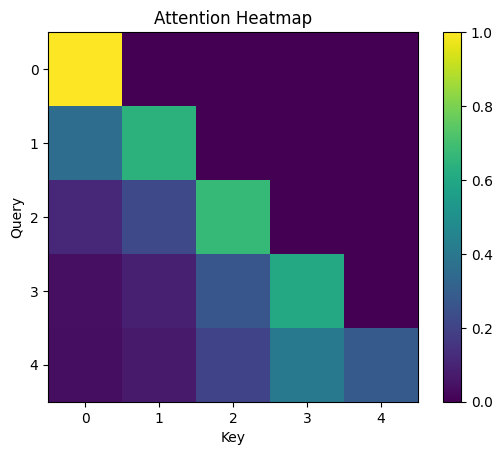

In [65]:
sample = tf.expand_dims(X[0], axis=0)

_, attention = model(sample, training=False)

attn_matrix = attention['block_1'][0][0].numpy()

plt.imshow(attn_matrix)
plt.title("Attention Heatmap")
plt.xlabel("Key")
plt.ylabel("Query")
plt.colorbar()
plt.show()
